# UMAP: Exemplos

## Introdução

Esse notebook tem como objetivo demonstrar alguns exemplos de como aplicar o algoritmo do UMAP em diferentes conjuntos de dados. Primeiro, vamos ver como o algoritmo lida com as relações semânticas entre palavras do conjunto *word2vec*. Então, vamos explorar uma das principais aplicações do UMAP no ramo da bioinformática. Caso queira entender de forma geral como funciona o algoritmo aqui utilizado, ou então se deseja um entendimento mais aprofundado quanto à matemática por trás do algoritmo, confira os notebooks [00 - Visão Geral](00%20-%20Visão%20Geral.ipynb) e [01 - UMAP Detalhado.ipynb](01%20-%20UMAP%20Detalhado.ipynb) respectivamente.

## Word2Vec

Conjuntos de dados Word2Vec são essenciais para algoritmos de processamento de liguagem natural. Neles, palavras são vetorizadas de acordo com o contexto em que aparecem, fazendo com que relações semânticas surjam. Com esses vetores, é possível realizar até mesmo aritimética simples. Por exemplo: se pegarmos o vetor da palavra $REI$ e subtrairmos $HOMEM$ enquanto adicionamos $MULHER$, o vetor resultante será muito próximo do vetor de $RAINHA$.

O dataset utilizado aqui será uma versão modificada do `Google Word2Vec` [[1](#referências)]. Nessa versão, 500 palavras foram selecionadas, de acordo com 5 categorias: Natureza e Biologia, Ciência e Tecnologia, Sociedade e Política, Geografia e Lugares, e, por último, Arte e Cultura. os datasets estão na pasta `datasets`, e podem ser carregados com o pandas

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_word2vec = pd.read_csv("../datasets/word2vec.csv")
df_word2vec.head()

,word,category,0,1,2,3,4,5,6,7,...,290,291,292,293,294,295,296,297,298,299
0,animal,Natureza e Biologia,0.008118,0.205078,-0.169922,0.118164,-0.115723,0.029907,0.176758,-0.038330,...,-0.271484,0.117676,-0.219727,0.285156,-0.011292,0.241211,0.126953,0.369141,-0.109863,0.187500
1,bird,Natureza e Biologia,0.084473,0.125000,-0.337891,0.029541,-0.016235,-0.077637,0.071289,0.104980,...,-0.124023,0.064941,-0.024292,-0.068359,0.000076,0.047363,0.152344,0.082520,0.127930,0.106445
2,fish,Natureza e Biologia,-0.174805,0.159180,0.004150,0.075195,-0.097656,0.122070,-0.158203,0.071777,...,-0.090820,-0.131836,-0.124512,-0.249023,0.085449,0.014160,-0.065918,-0.018433,0.300781,0.085449
3,dog,Natureza e Biologia,0.051270,-0.022339,-0.172852,0.161133,-0.084473,0.057373,0.058594,-0.082520,...,-0.180664,0.103027,-0.275391,0.261719,0.246094,-0.047119,0.062500,0.416016,-0.355469,0.222656
4,cat,Natureza e Biologia,0.012329,0.204102,-0.285156,0.216797,0.118164,0.083008,0.049805,-0.009521,...,-0.206055,0.180664,-0.158203,0.059326,0.287109,-0.046631,0.151367,0.492188,-0.275391,0.056152


Como podemos ver, cada palavra representa um vetor hiperdimensional com 300 componentes, o que é praticamente impossível de se enxergar caso não seja projetado em uma dimensão menor. Também temos uma coluna que relaciona a categoria de cada palavra (definida préviamente).

Agora, podemos aplicar o UMAP no conjunto obtido para visualizar a relação entre as palavras de diferentes categorias. Primeiro, importamos a biblioteca do UMAP.

In [3]:
import umap

Agora, instanciamos um `reducer` para poder aplicar o algoritmo. Aqui, utilizaremos os hiperparâmetros `n_neighbors`=15 e `min_dist`=0.4, pois foram parâmetros que geraram uma boa visualização. Você pode variar esses parâmetros para observar como altera o resultado final da projeção.

In [4]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.4)

Então, podemos ajustar o reducer de acordo com nosso conjunto, e então gerar o novo conjunto com apenas duas dimensões.

In [5]:
df_vectors = df_word2vec.drop(columns=["word", "category"])

reducer.fit(df_vectors)

embeddings = reducer.transform(df_vectors)
embeddings.shape

(500, 2)

Podemos ver que o resultado consistem em 500 observações (uma para cada palavra), com apenas duas dimensões. Isso fica muito mais fácil para plotarmos

In [6]:
import matplotlib.pyplot as plt

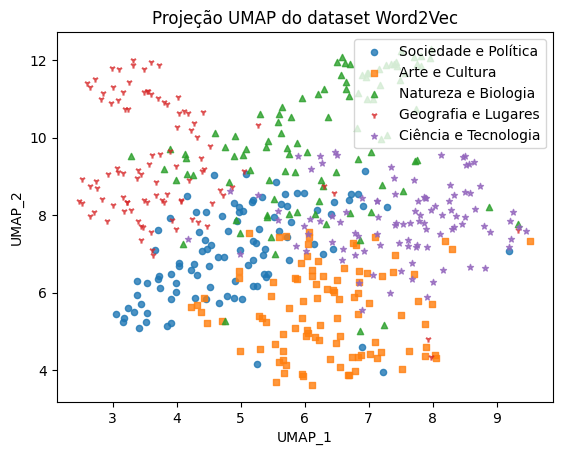

In [7]:
for category, marker in zip(set(df_word2vec["category"]), ["o", "s", "^", "1", "*"]):
    plt.scatter(
        embeddings[:, 0][df_word2vec["category"] == category],
        embeddings[:, 1][df_word2vec["category"] == category],
        label=category,
        marker=marker,
        alpha=0.8,
        s=20
    )

plt.title("Projeção UMAP do dataset Word2Vec")
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.legend()
plt.show()

É possível observar como existe uma certa separação entre as categorias de forma geral, mesmo sem passarmos essa informação na hora de gerar o conjunto de baixa dimensão. Mas ainda assim algumas palavras se misturam. Vamos ver alguns exemplos dessas palavras a partir do gráfico a seguir:

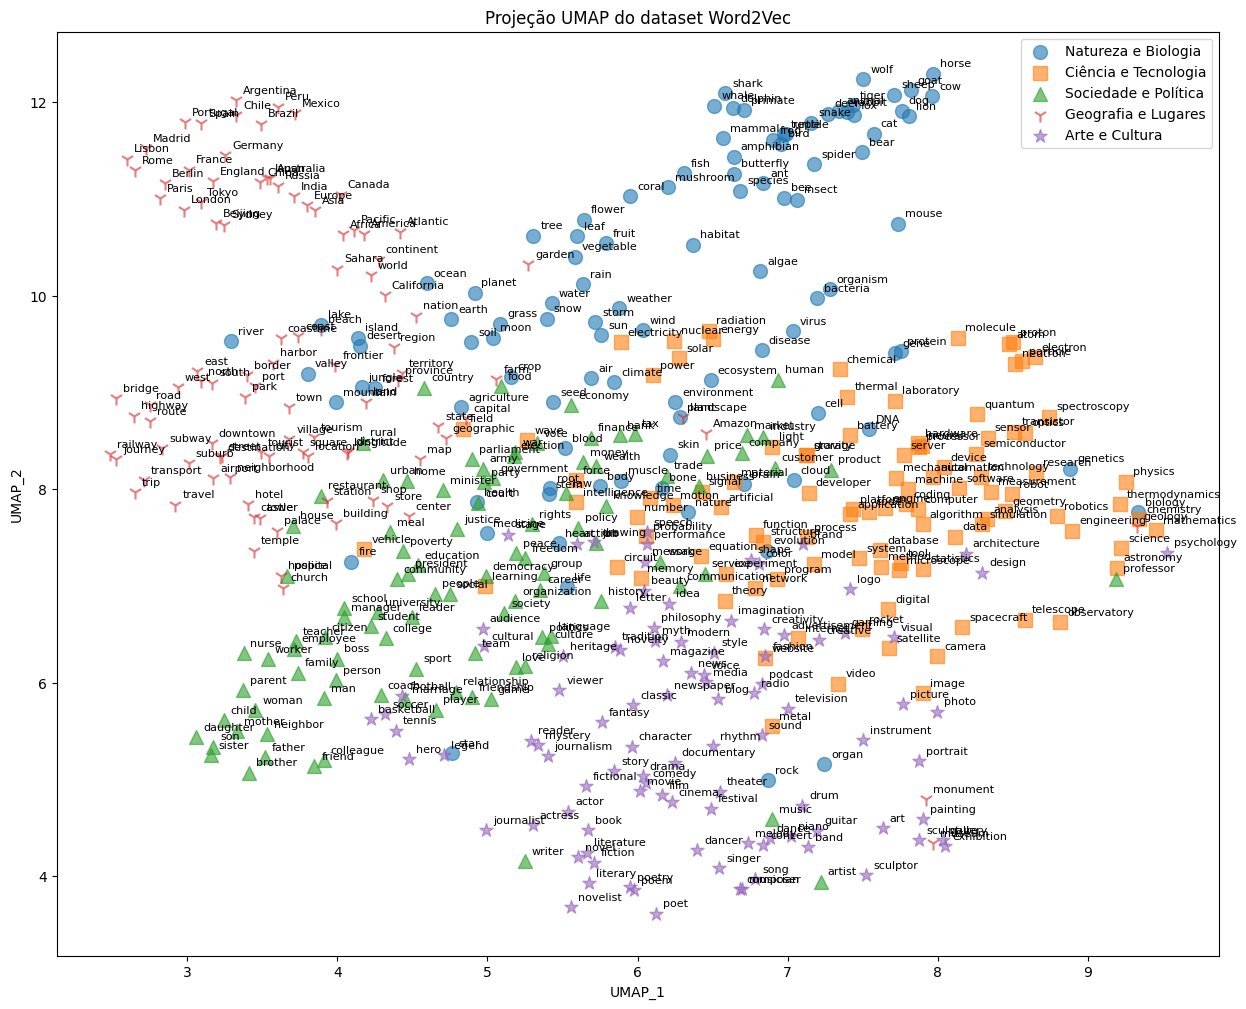

In [8]:
fig, ax = plt.subplots(figsize=(15, 12))

categories = df_word2vec["category"].unique()

for category, marker in zip(categories, ["o", "s", "^", "1", "*"]):

    mask = df_word2vec["category"] == category

    ax.scatter(
        embeddings[:, 0][mask],
        embeddings[:, 1][mask],
        label=category,
        marker=marker,
        alpha=0.6,
        s=100
    )

    for x, y, word in zip(
        embeddings[:, 0][mask],
        embeddings[:, 1][mask],
        df_word2vec[mask]["word"]
    ):
        ax.annotate(
            word,
            xy=(x, y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

ax.set_title("Projeção UMAP do dataset Word2Vec")
ax.set_xlabel("UMAP_1")
ax.set_ylabel("UMAP_2")
ax.legend()

plt.show()

É interessante ver como algumas palavras foram confundidas por possuirem mais de um significado possível. Por exemplo: a palavra `rock` (pedra), que, originalmente, era da categoria de *Natureza e Biologia*, ficou mais próxima de palavras da categoria de *Arte e Cultura*, provavelmente por conta do estilo musical. O mesmo aconteceu com `metal`, que ficou entre sua categoria original (*Ciência e Tecnologia*), e a categoria de *Arte e Cultura*.

Outros casos interessantes foram das palavras `gene`, `genetics`, `protein`, `biology` e `DNA`, as quais tinhamos definido que seria da categoria *Natureza e Biologia*, porém se aprozimaram muito mais das palavras utilizadas em um contexto de *Ciência e Tecnologia*.

## Single-Cell Transcriptomics

Transcriptomas de células unicas são essenciais para desvendar populações celulares heterogêneas, reconstruir vias de desenvolvimento celular e modelar a dinâmica transcricional. [[2](#referências)]. Neles, temos a quantificação da expressão gênica de células individuais.

Nesse caso, vamos utilizar uma versão modificada do conjunto `Tabula Muris`, que é um atlas transcritômico de célula única do camundongo *Mus musculus*. [[3](#referências)]. Vamos importá-lo com o pandas primeiramente. Nessa versão, o número de genes foi reduzido de acordo com a variância, para minimizar o tamanho do arquivo. Para os fins didáticos desse notebook, essa versão já está suficiente.

In [9]:
df_brain_counts = pd.read_csv("../datasets/brain_counts.csv", index_col=0)
df_brain_counts.head()

,Rn45s,Plp1,Trf,Mbp,Apoe,Malat1,ERCC-00096,Ptgds,Cnp,ERCC-00002,...,Npm3,D3Ertd751e,Rtf1,Atp13a5,Brwd3,Ralgapa2,Zfp101,G2e3,Bicc1,cell_ontology_class
A1.B003290.3_38_F.1.1,16643,1,2,0,3938,2222,2877,1,32,2234,...,0,0,3,0,0,0,0,0,20,astrocyte
A1.B003728.3_56_F.1.1,33642,4,0,294,35244,13975,15910,0,6,10300,...,0,0,0,0,0,0,0,0,336,astrocyte
A1.MAA000560.3_10_M.1.1,196795,90388,29652,27022,6229,9865,7086,42732,21388,8816,...,0,0,0,0,0,0,1,0,0,oligodendrocyte
A1.MAA000564.3_10_M.1.1,63313,1,0,0,473,2476,751,0,1,436,...,9,0,0,0,0,0,0,0,0,endothelial cell
A1.MAA000923.3_9_M.1.1,123577,0,0,0,5249,3374,2879,0,57,2039,...,0,0,0,0,0,0,97,0,0,astrocyte


Nesse conjunto, cada linha representa uma célula enquanto cada coluna indica um gene específico. Sendo assim, temos um conjunto de células em um espaço hiperdimensional de genes. Também temos uma coluna que indica o tipo de cada célula, a qual utilizaremos posteriormente para a visualização.

Vamos começar tratando o conjunto de dados obtidos. Para isso vamos remover a coluna com a identificação de cada célula e normalizar com a normalização `LogNormalize`, frequentemente utilizada em pipelines de análise transcriptomica [[5](#referências)].

Existem outras ténicas de pré-processamento que poderiam ser utilizadas para aprimorar o resultado final, mas para o objetivo desse notebook, apenas essa normalização já basta.

In [13]:
X = df_brain_counts.drop("cell_ontology_class", axis=1)

X = X.div(X.sum(axis=1), axis=0) * 10000
X = np.log1p(X)

Então, podemos instanciar o objeto UMAP e ajustá-lo de acordo com nosso conjunto. Por fim, criamos o embeddings com as dimensões reduzidas.

In [14]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
reducer.fit(X)
embeddings = reducer.transform(X)

Agora podemos plotar as células de acordo com as classes dos metadados

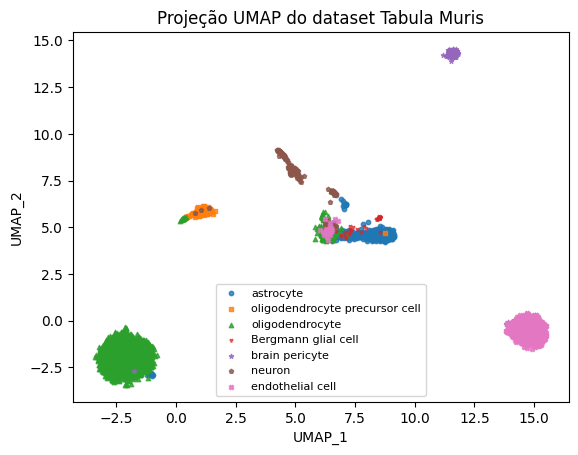

In [15]:
# plt.figure(figsize=(15,12))

for cell_class, marker in zip(set(df_brain_counts["cell_ontology_class"]), ["o", "s", "^", "1", "*", "p", "X"]):
    plt.scatter(
        embeddings[:, 0][df_brain_counts["cell_ontology_class"] == cell_class],
        embeddings[:, 1][df_brain_counts["cell_ontology_class"] == cell_class],
        label=cell_class,
        marker=marker,
        alpha=0.8,
        s=10
    )

plt.title("Projeção UMAP do dataset Tabula Muris")
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.legend(prop={'size': 8})
plt.show()

Novamente, conseguimos observar como o UMAP tende a separar as formas gerais de cada tipo de célula apenas pelos padrões de expressão gênica. Mesmo assim, ainda existem alguns grupos que se misturaram um pouco. Isso poderia ser evitado utilizando técnicas mais avançadas para pré-processar as informações.

## Referências

1. **GHOSH, Sugata.** *Google Word2Vec*. Kaggle, [s. d.]. Disponível em: <https://www.kaggle.com/datasets/sugataghosh/google-word2vec>. Acesso em: 5 out. 2026.

2. **WIKIPEDIA CONTRIBUTORS.** *Single-cell transcriptomics*. Wikipedia, [s. d.]. Disponível em: <https://en.wikipedia.org/wiki/Single-cell_transcriptomics>. Acesso em: 5 out. 2026.

3. **AAYUSH9753.** *Singlecell RNAseq Data from Mouse Brain*. Kaggle, [s. d.]. Disponível em: <https://www.kaggle.com/datasets/aayush9753/singlecell-rnaseq-data-from-mouse-brain>. Acesso em: 5 out. 2026.

4. **MATPLOTLIB CONTRIBUTORS.** *matplotlib.markers — Matplotlib 3.11.2 documentation*. Matplotlib, 2026. Disponível em: <https://matplotlib.org/stable/api/markers_api.html>. Acesso em: 5 out. 2026.

5. **SCVERSE.** *Clustering — Scanpy*. Scanpy, [s. d.]. Disponível em: <https://scanpy.readthedocs.io/en/latest/tutorials/basics/clustering.html>. Acesso em: 5 out. 2026.